# Sine wave prediction using LSTM

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)

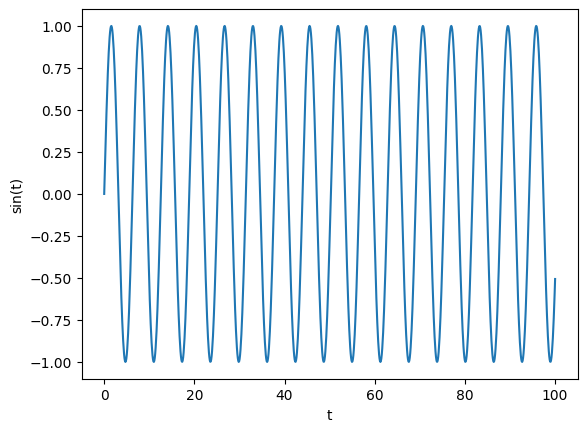

In [135]:
t = np.linspace(0, 100, 1000)
data = np.sin(t)
train = data[:int(len(data)*0.8)]
train_t = t[:int(len(data)*0.8)]
test = data[int(len(data)*0.8):]
test_t = t[int(len(data)*0.8):]

plt.plot(t, data)
plt.xlabel("t")
plt.ylabel("sin(t)")
plt.show()

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)\

seq_length = 10
X_train, y_train = create_sequences(train, seq_length)
X_test, y_test = create_sequences(test, seq_length)

X_train = torch.tensor(X_train[:, :, None], dtype=torch.float32)
y_train = torch.tensor(y_train[:, None], dtype=torch.float32)
X_test = torch.tensor(X_test[:, :, None], dtype=torch.float32)
y_test = torch.tensor(y_test[:, None], dtype=torch.float32)

In [124]:
class LSTMModel(nn.Module):
    """Physics-Informed LSTM"""
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [125]:
model = LSTMModel(input_size=1, hidden_size=100, num_layers=1, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [126]:
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.1284
Epoch [20/100], Loss: 0.0431
Epoch [30/100], Loss: 0.0081
Epoch [40/100], Loss: 0.0034
Epoch [50/100], Loss: 0.0005
Epoch [60/100], Loss: 0.0002
Epoch [70/100], Loss: 0.0002
Epoch [80/100], Loss: 0.0001
Epoch [90/100], Loss: 0.0000
Epoch [100/100], Loss: 0.0000


In [127]:
colours = {
    "Ground truth": "#1589e8",
    "LSTM": "#dc267f",
    "Starting data": "#631ff3"
}

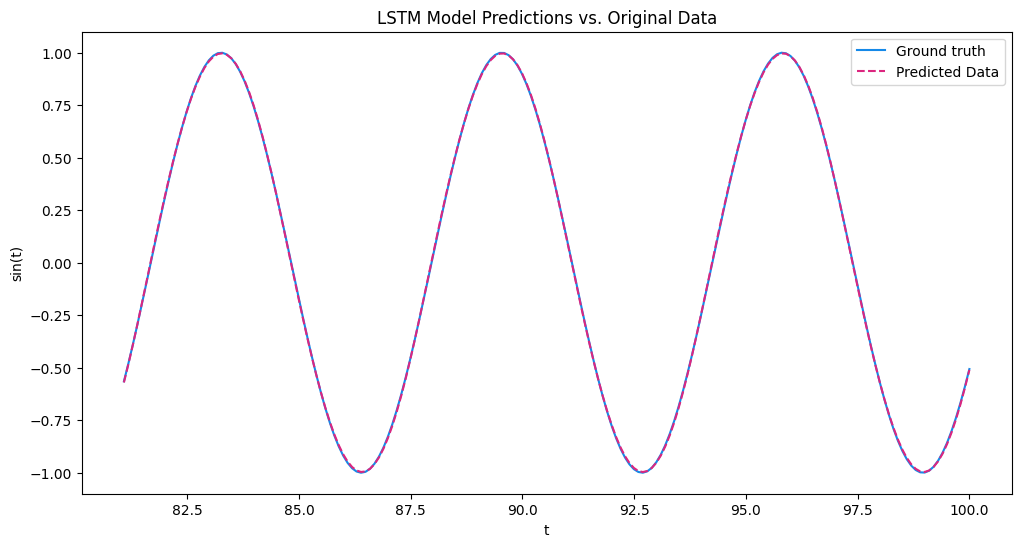

In [134]:
model.eval()
predicted = model(X_test)

original = test[seq_length:]
time_steps = test_t[seq_length:]

plt.figure(figsize=(12, 6))
plt.plot(time_steps, original, label='Ground truth', c=colours["Ground truth"])
plt.plot(time_steps, predicted.detach().numpy(),
         label='Predicted Data', linestyle='--', c=colours["LSTM"])
plt.title('LSTM Model Predictions vs. Original Data')
plt.xlabel("t")
plt.ylabel("sin(t)")
plt.legend()
plt.show()

In [ ]:
def forecast_with_model(model, forecast_length, start_data):
    """Autoregressive forecasting across test set with model
    
    Args:
        model (pytorch model):
        forecast_length (int): length of data to forecast
        start_data (pytorch Tensor): tensor containing the starting data sequence to forecast from
    Returns:
        y_forecast (numpy array): array of length len_test forecasted predictions
    """
    # Take last set from X_train
    X_forecast = start_data
    y_forecast = []
    for i in range(forecast_length):
        # Make prediction:
        pred = model(X_forecast).squeeze().detach().numpy()
        y_forecast.append(pred)
                
        # Make new window
        X_old = X_forecast.squeeze().numpy()[1:]  # Convert to numpy and drop first value
        X_new = np.array([np.append(X_old, pred)])  # Add prediction on end of window
        X_forecast = torch.Tensor(X_new).unsqueeze(-1)  # Convert new window to pytorch tensor
    
    y_forecast = np.array(y_forecast)  # Sort out formatting of results into a numpy array
    return y_forecast

In [130]:
start_data = X_train[-1:]
y_forecast = forecast_with_model(model, len(test), start_data)

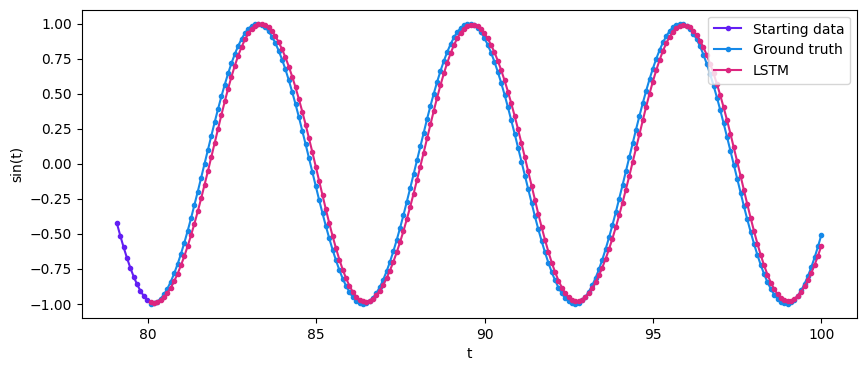

In [133]:
time_steps = test_t # entire test set
plt.figure(figsize=(10, 4))
plt.plot(train_t[-seq_length:], start_data.squeeze(), marker='.', label='Starting data', c=colours['Starting data'])
plt.plot(time_steps, test, label='Ground truth', marker='.', c=colours['Ground truth'])
plt.plot(time_steps, y_forecast, label='LSTM', marker='.', c=colours['LSTM'])
plt.xlabel("t")
plt.ylabel("sin(t)")
plt.legend(loc='upper right')